# Bias–Variance Trade-off and Regularization with PyTorch MLPs

This notebook uses **PyTorch multilayer perceptrons (MLPs)** to demonstrate:

1. **Bias–variance trade-off**
2. **L2 regularization** (`weight_decay`)
3. **Adding noise to inputs and outputs**
4. **Ensemble bagging**
5. **Data augmentation**
6. **Dropout**

We use two datasets:

- A **synthetic regression dataset** to make bias and variance easy to visualize
- The **`sklearn` digits dataset** for classification, augmentation, and dropout

The main idea is to keep the models conceptually consistent:  
we use **MLPs in PyTorch throughout**, instead of mixing linear models, trees, and neural networks.

## Why these datasets?

### 1) Synthetic regression data
A 1D synthetic regression problem is ideal for explaining the **bias–variance trade-off** because:

- the true function is known,
- model predictions can be plotted directly,
- overfitting and underfitting are easy to see.

It is also a good setting for:

- **L2 regularization**
- **noise injection**
- **bagging**

### 2) Digits dataset
The digits dataset contains small **8×8 grayscale images** of handwritten digits.  
It is lightweight, fast on CPU, and suitable for:

- **MLP classification**
- **data augmentation**
- **dropout**

In [1]:

import copy
import math
import random
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, accuracy_score, classification_report

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cpu


In [2]:

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

## Helper functions

We define small reusable utilities for:

- creating regression and classification MLPs,
- training loops,
- evaluation,
- plotting.

In [3]:

class RegressionMLP(nn.Module):
    def __init__(self, hidden_sizes=(32,), dropout=0.0):
        super().__init__()
        layers = []
        in_features = 1
        for h in hidden_sizes:
            layers.append(nn.Linear(in_features, h))
            layers.append(nn.Tanh())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            in_features = h
        layers.append(nn.Linear(in_features, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class ClassificationMLP(nn.Module):
    def __init__(self, input_dim=64, hidden_sizes=(128, 64), dropout=0.0, num_classes=10):
        super().__init__()
        layers = []
        in_features = input_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(in_features, h))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            in_features = h
        layers.append(nn.Linear(in_features, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def make_regression_loaders(X_train, y_train, X_val, y_val, batch_size=32):
    train_ds = TensorDataset(
        torch.tensor(X_train, dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1),
    )
    val_ds = TensorDataset(
        torch.tensor(X_val, dtype=torch.float32),
        torch.tensor(y_val, dtype=torch.float32).reshape(-1, 1),
    )
    return (
        DataLoader(train_ds, batch_size=batch_size, shuffle=True),
        DataLoader(val_ds, batch_size=batch_size, shuffle=False),
    )


def make_classification_loaders(X_train, y_train, X_val, y_val, batch_size=64):
    train_ds = TensorDataset(
        torch.tensor(X_train, dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.long),
    )
    val_ds = TensorDataset(
        torch.tensor(X_val, dtype=torch.float32),
        torch.tensor(y_val, dtype=torch.long),
    )
    return (
        DataLoader(train_ds, batch_size=batch_size, shuffle=True),
        DataLoader(val_ds, batch_size=batch_size, shuffle=False),
    )


def train_regression_model(
    model,
    train_loader,
    val_loader,
    epochs=200,
    lr=1e-2,
    weight_decay=0.0,
    verbose=False,
):
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {"train_loss": [], "val_loss": []}

    for epoch in range(epochs):
        model.train()
        train_losses = []
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                preds = model(xb)
                loss = criterion(preds, yb)
                val_losses.append(loss.item())

        history["train_loss"].append(float(np.mean(train_losses)))
        history["val_loss"].append(float(np.mean(val_losses)))

        if verbose and (epoch + 1) % 100 == 0:
            print(f"Epoch {epoch+1:4d} | train {history['train_loss'][-1]:.4f} | val {history['val_loss'][-1]:.4f}")

    return history


def predict_regression(model, X):
    model.eval()
    with torch.no_grad():
        X_tensor = torch.tensor(X, dtype=torch.float32).to(device)
        preds = model(X_tensor).cpu().numpy().reshape(-1)
    return preds


def train_classification_model(
    model,
    train_loader,
    val_loader,
    epochs=40,
    lr=1e-3,
    weight_decay=0.0,
    verbose=False,
):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):
        model.train()
        train_losses, train_correct, train_count = [], 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())
            train_correct += (logits.argmax(dim=1) == yb).sum().item()
            train_count += yb.size(0)

        model.eval()
        val_losses, val_correct, val_count = [], 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                loss = criterion(logits, yb)
                val_losses.append(loss.item())
                val_correct += (logits.argmax(dim=1) == yb).sum().item()
                val_count += yb.size(0)

        history["train_loss"].append(float(np.mean(train_losses)))
        history["val_loss"].append(float(np.mean(val_losses)))
        history["train_acc"].append(train_correct / train_count)
        history["val_acc"].append(val_correct / val_count)

        if verbose and (epoch + 1) % 10 == 0:
            print(
                f"Epoch {epoch+1:3d} | "
                f"train loss {history['train_loss'][-1]:.4f} | val loss {history['val_loss'][-1]:.4f} | "
                f"train acc {history['train_acc'][-1]:.3f} | val acc {history['val_acc'][-1]:.3f}"
            )

    return history


def predict_classification(model, X):
    model.eval()
    with torch.no_grad():
        logits = model(torch.tensor(X, dtype=torch.float32).to(device))
        preds = logits.argmax(dim=1).cpu().numpy()
    return preds

## Part A — Bias–Variance, L2, Noise, and Bagging on a Synthetic Regression Dataset

### 1. Create a Synthetic Regression Dataset

We generate data from a smooth nonlinear function:

$$
y = \sin(1.5\pi x) + \epsilon
$$

where $\epsilon$ is random noise.

This gives us:

- A known underlying signal  
- Noisy observations  
- A clean setup to visualize what an MLP learns

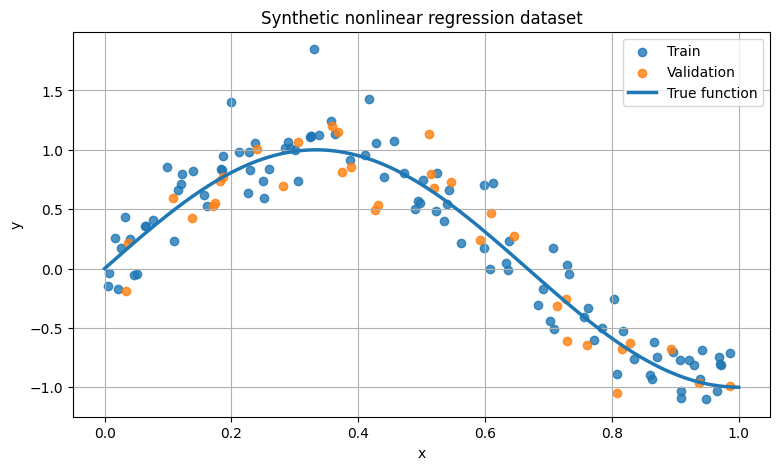

Train size: 101 | Val size: 34 | Test size: 45


In [4]:

def true_function(x):
    return np.sin(1.5 * np.pi * x)

n_total = 180
X_all = np.sort(np.random.rand(n_total)).reshape(-1, 1)
y_all = true_function(X_all[:, 0]) + np.random.normal(scale=0.22, size=n_total)

X_temp, X_test, y_temp, y_test = train_test_split(X_all, y_all, test_size=0.25, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=SEED)

X_plot = np.linspace(0, 1, 500).reshape(-1, 1)
y_true = true_function(X_plot[:, 0])

plt.figure(figsize=(9, 5))
plt.scatter(X_train[:, 0], y_train, label="Train", alpha=0.8)
plt.scatter(X_val[:, 0], y_val, label="Validation", alpha=0.8)
plt.plot(X_plot[:, 0], y_true, linewidth=2.5, label="True function")
plt.title("Synthetic nonlinear regression dataset")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

print("Train size:", len(X_train), "| Val size:", len(X_val), "| Test size:", len(X_test))

### 2. Bias–variance trade-off with MLP capacity

We train three MLPs:

- **Small MLP** → likely **high bias**
- **Medium MLP** → often a better balance
- **Large MLP** → likely **high variance**

To make the contrast stronger, we deliberately keep the training set modest in size.

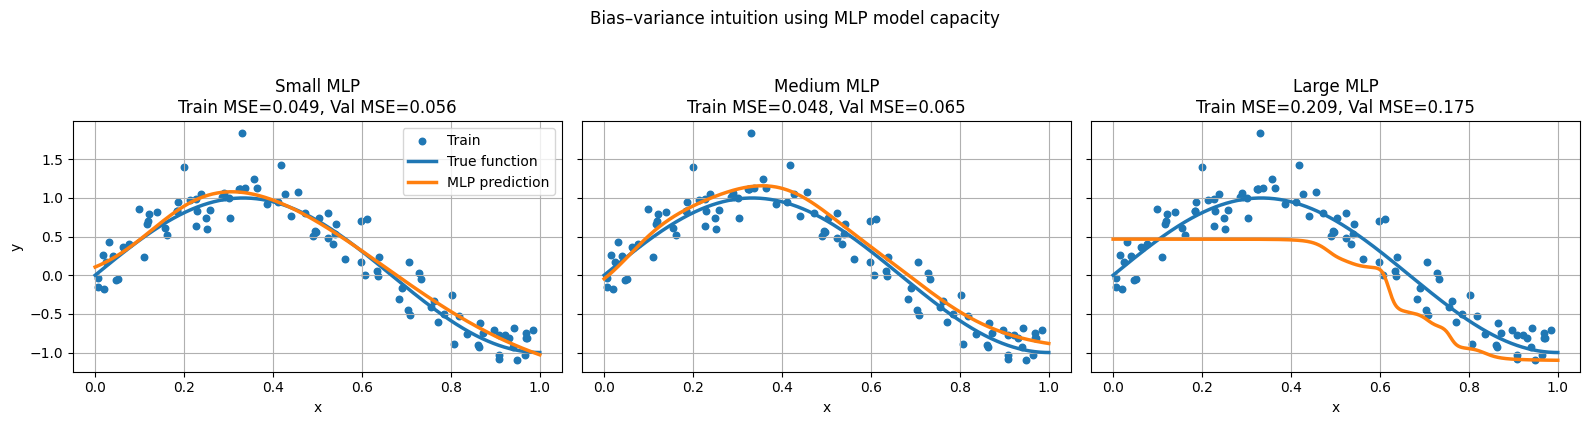

In [5]:

train_loader, val_loader = make_regression_loaders(X_train, y_train, X_val, y_val, batch_size=32)

capacity_configs = {
    "Small MLP": (4,),
    "Medium MLP": (32, 32),
    "Large MLP": (256, 256, 256),
}

capacity_results = {}

for name, hidden_sizes in capacity_configs.items():
    model = RegressionMLP(hidden_sizes=hidden_sizes, dropout=0.0)
    history = train_regression_model(
        model,
        train_loader,
        val_loader,
        epochs=250,
        lr=1e-2,
        weight_decay=0.0,
        verbose=False,
    )
    preds = predict_regression(model, X_plot)
    train_preds = predict_regression(model, X_train)
    val_preds = predict_regression(model, X_val)

    capacity_results[name] = {
        "model": model,
        "history": history,
        "plot_preds": preds,
        "train_mse": mean_squared_error(y_train, train_preds),
        "val_mse": mean_squared_error(y_val, val_preds),
    }

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, (name, result) in zip(axes, capacity_results.items()):
    ax.scatter(X_train[:, 0], y_train, s=22, label="Train")
    ax.plot(X_plot[:, 0], y_true, linewidth=2.5, label="True function")
    ax.plot(X_plot[:, 0], result["plot_preds"], linewidth=2.5, label="MLP prediction")
    ax.set_title(f"{name}\nTrain MSE={result['train_mse']:.3f}, Val MSE={result['val_mse']:.3f}")
    ax.set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].legend(loc="best")
plt.suptitle("Bias–variance intuition using MLP model capacity", y=1.05)
plt.tight_layout()
plt.show()

In [6]:

capacity_table = pd.DataFrame([
    {
        "model": name,
        "hidden_sizes": str(capacity_configs[name]),
        "train_mse": result["train_mse"],
        "val_mse": result["val_mse"],
    }
    for name, result in capacity_results.items()
]).sort_values("val_mse")

capacity_table

,model,hidden_sizes,train_mse,val_mse
0,Small MLP,"(4,)",0.048610,0.056086
1,Medium MLP,"(32, 32)",0.047708,0.064708
2,Large MLP,"(256, 256, 256)",0.208840,0.174965


### Interpretation

A typical pattern is:

- the **small MLP** is too rigid and underfits → **high bias**
- the **large MLP** can become too flexible and follow noise → **high variance**
- the **medium MLP** often gives a better train/validation balance

This is the practical meaning of the **bias–variance trade-off**:
a model that is too simple misses structure, while a model that is too flexible becomes unstable.

### 3. Training curves for the same models

Looking at the training and validation losses over epochs helps explain **where** underfitting and overfitting come from.

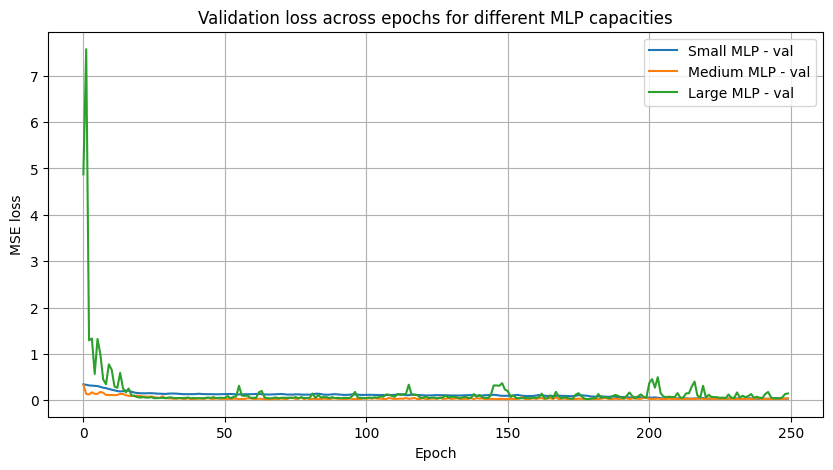

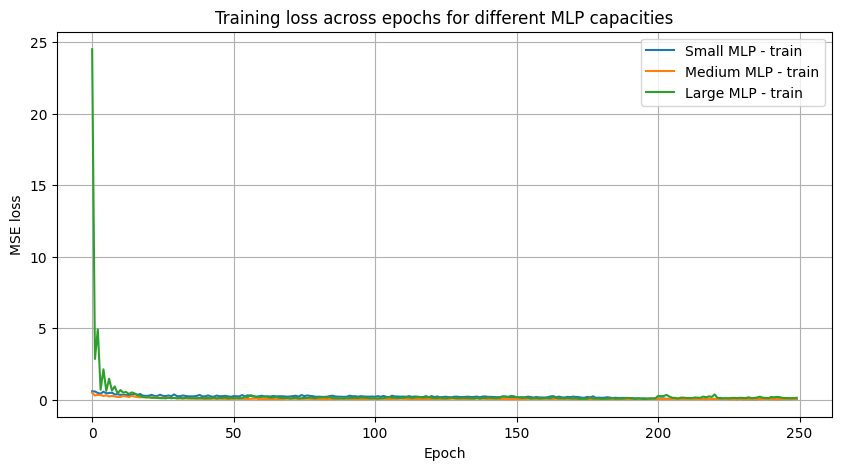

In [7]:

plt.figure(figsize=(10, 5))
for name, result in capacity_results.items():
    plt.plot(result["history"]["val_loss"], label=f"{name} - val")
plt.title("Validation loss across epochs for different MLP capacities")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
for name, result in capacity_results.items():
    plt.plot(result["history"]["train_loss"], label=f"{name} - train")
plt.title("Training loss across epochs for different MLP capacities")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.legend()
plt.show()

## 4. L2 regularization with `weight_decay`

In PyTorch, **L2 regularization** is typically implemented using the `weight_decay` parameter in the optimizer.

Conceptually, the loss function becomes:

$$
\text{Loss} = \text{MSE} + \lambda \sum_j w_j^2
$$

Where:

- **MSE** encourages the model to fit the data,
- **L2 regularization** penalizes large weights,
- A larger `weight_decay` corresponds to stronger regularization.

In this experiment, we keep a **large MLP model** fixed and vary the regularization strength to observe its effect on model behavior.

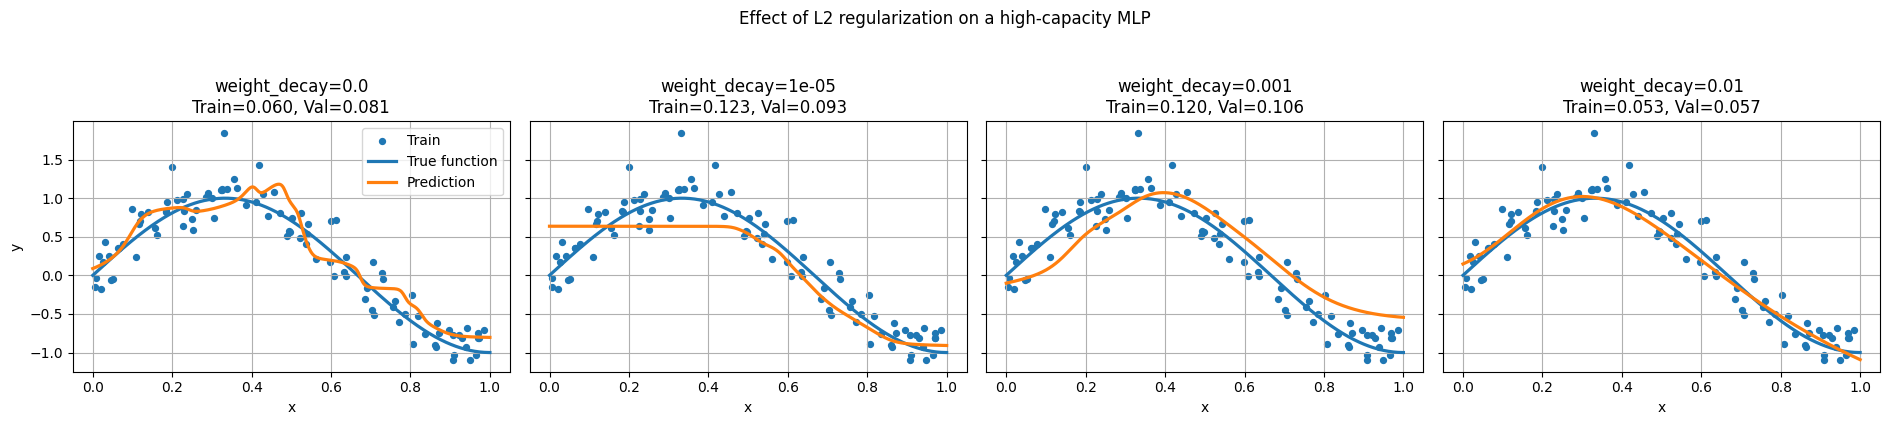

In [8]:

l2_settings = [0.0, 1e-5, 1e-3, 1e-2]
l2_results = {}

for wd in l2_settings:
    model = RegressionMLP(hidden_sizes=(256, 256, 256), dropout=0.0)
    history = train_regression_model(
        model,
        train_loader,
        val_loader,
        epochs=250,
        lr=1e-2,
        weight_decay=wd,
        verbose=False,
    )
    l2_results[wd] = {
        "model": model,
        "history": history,
        "plot_preds": predict_regression(model, X_plot),
        "train_mse": mean_squared_error(y_train, predict_regression(model, X_train)),
        "val_mse": mean_squared_error(y_val, predict_regression(model, X_val)),
    }

fig, axes = plt.subplots(1, 4, figsize=(19, 4), sharey=True)
for ax, wd in zip(axes, l2_settings):
    result = l2_results[wd]
    ax.scatter(X_train[:, 0], y_train, s=18, label="Train")
    ax.plot(X_plot[:, 0], y_true, linewidth=2.3, label="True function")
    ax.plot(X_plot[:, 0], result["plot_preds"], linewidth=2.3, label="Prediction")
    ax.set_title(f"weight_decay={wd}\nTrain={result['train_mse']:.3f}, Val={result['val_mse']:.3f}")
    ax.set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].legend(loc="best")
plt.suptitle("Effect of L2 regularization on a high-capacity MLP", y=1.05)
plt.tight_layout()
plt.show()

In [9]:

pd.DataFrame([
    {
        "weight_decay": wd,
        "train_mse": result["train_mse"],
        "val_mse": result["val_mse"],
    }
    for wd, result in l2_results.items()
]).sort_values("val_mse")

,weight_decay,train_mse,val_mse
3,0.01000,0.052712,0.056727
0,0.00000,0.059629,0.081255
1,0.00001,0.122518,0.092535
2,0.00100,0.120351,0.105525


### Interpretation

Typical behavior:

- **No L2**: the model may fit noise too aggressively
- **Small to moderate L2**: often improves validation error
- **Too much L2**: can oversmooth the model and increase bias

So L2 does not only "reduce overfitting" in a vague sense.  
It specifically reduces the tendency of a flexible model to use large, unstable weights.

## 5. Adding noise to inputs and outputs

Noise is useful in two different ways:

1. It helps us understand why learning becomes harder
2. In controlled settings, it can act like a regularizer

We compare three training scenarios for the same MLP:

- clean data
- noisy inputs
- noisy outputs

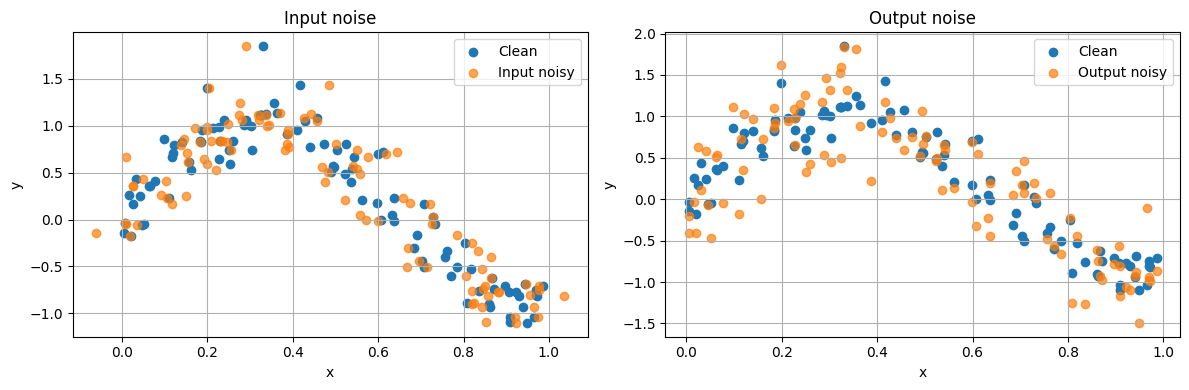

In [10]:

def add_input_noise(X, sigma=0.04):
    return X + np.random.normal(scale=sigma, size=X.shape)

def add_output_noise(y, sigma=0.25):
    return y + np.random.normal(scale=sigma, size=y.shape)

X_train_input_noisy = add_input_noise(X_train, sigma=0.05)
y_train_output_noisy = add_output_noise(y_train, sigma=0.30)

noise_scenarios = {
    "Clean": (X_train, y_train),
    "Noisy inputs": (X_train_input_noisy, y_train),
    "Noisy outputs": (X_train, y_train_output_noisy),
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(X_train[:, 0], y_train, label="Clean")
axes[0].scatter(X_train_input_noisy[:, 0], y_train, alpha=0.7, label="Input noisy")
axes[0].set_title("Input noise")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].legend()

axes[1].scatter(X_train[:, 0], y_train, label="Clean")
axes[1].scatter(X_train[:, 0], y_train_output_noisy, alpha=0.7, label="Output noisy")
axes[1].set_title("Output noise")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].legend()

plt.tight_layout()
plt.show()

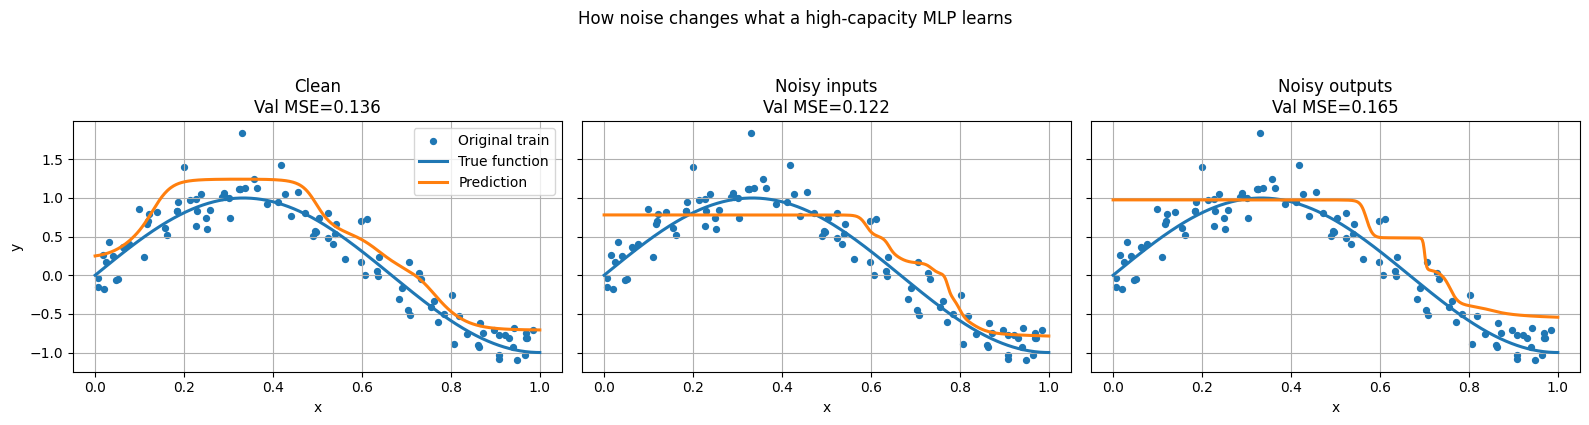

In [11]:

noise_results = {}
for name, (Xt, yt) in noise_scenarios.items():
    tr_loader, va_loader = make_regression_loaders(Xt, yt, X_val, y_val, batch_size=32)
    model = RegressionMLP(hidden_sizes=(256, 256, 256), dropout=0.0)
    history = train_regression_model(
        model,
        tr_loader,
        va_loader,
        epochs=200,
        lr=1e-2,
        weight_decay=0.0,
        verbose=False,
    )
    noise_results[name] = {
        "model": model,
        "history": history,
        "plot_preds": predict_regression(model, X_plot),
        "train_mse_on_seen_targets": mean_squared_error(yt, predict_regression(model, Xt)),
        "val_mse": mean_squared_error(y_val, predict_regression(model, X_val)),
    }

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, (name, result) in zip(axes, noise_results.items()):
    ax.scatter(X_train[:, 0], y_train, s=18, label="Original train")
    ax.plot(X_plot[:, 0], y_true, linewidth=2.2, label="True function")
    ax.plot(X_plot[:, 0], result["plot_preds"], linewidth=2.2, label="Prediction")
    ax.set_title(f"{name}\nVal MSE={result['val_mse']:.3f}")
    ax.set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].legend(loc="best")
plt.suptitle("How noise changes what a high-capacity MLP learns", y=1.05)
plt.tight_layout()
plt.show()

In [12]:

pd.DataFrame([
    {
        "scenario": name,
        "train_mse_on_seen_targets": result["train_mse_on_seen_targets"],
        "val_mse": result["val_mse"],
    }
    for name, result in noise_results.items()
]).sort_values("val_mse")

,scenario,train_mse_on_seen_targets,val_mse
1,Noisy inputs,0.142416,0.121774
0,Clean,0.082120,0.135517
2,Noisy outputs,0.307579,0.165360


### Interpretation

- **Input noise** changes the locations of the features and can distort the learned mapping
- **Output noise** corrupts the target itself and often makes overfitting worse
- A highly flexible MLP is sensitive to both kinds of noise

This connects directly to variance:
small data perturbations can produce noticeably different learned functions.

## 6. Ensemble bagging with MLP regressors

**Bagging** means:

1. sample multiple bootstrap datasets from the training set,
2. train one model on each bootstrap sample,
3. average their predictions.

Bagging is useful because it often reduces **variance**:
individual overfit models may disagree, but their average is usually more stable.

In [13]:

def bootstrap_sample(X, y):
    idx = np.random.choice(len(X), size=len(X), replace=True)
    return X[idx], y[idx]

# single large MLP baseline
single_model = RegressionMLP(hidden_sizes=(256, 256, 256), dropout=0.0)
single_history = train_regression_model(
    single_model,
    train_loader,
    val_loader,
    epochs=200,
    lr=1e-2,
    weight_decay=0.0,
)
single_preds_plot = predict_regression(single_model, X_plot)
single_val_mse = mean_squared_error(y_val, predict_regression(single_model, X_val))

# bagging ensemble of MLPs
n_members = 7
ensemble_models = []
ensemble_member_preds_plot = []

for i in range(n_members):
    X_boot, y_boot = bootstrap_sample(X_train, y_train)
    tr_loader_boot, va_loader_boot = make_regression_loaders(X_boot, y_boot, X_val, y_val, batch_size=32)
    model = RegressionMLP(hidden_sizes=(256, 256, 256), dropout=0.0)
    _ = train_regression_model(
        model,
        tr_loader_boot,
        va_loader_boot,
        epochs=180,
        lr=1e-2,
        weight_decay=0.0,
    )
    ensemble_models.append(model)
    ensemble_member_preds_plot.append(predict_regression(model, X_plot))

ensemble_member_preds_plot = np.array(ensemble_member_preds_plot)
ensemble_preds_plot = ensemble_member_preds_plot.mean(axis=0)

ensemble_val_preds = np.mean([predict_regression(m, X_val) for m in ensemble_models], axis=0)
ensemble_val_mse = mean_squared_error(y_val, ensemble_val_preds)

print("Single large MLP validation MSE:", round(single_val_mse, 4))
print("Bagged MLP ensemble validation MSE:", round(ensemble_val_mse, 4))

Single large MLP validation MSE: 0.2331
Bagged MLP ensemble validation MSE: 0.0938


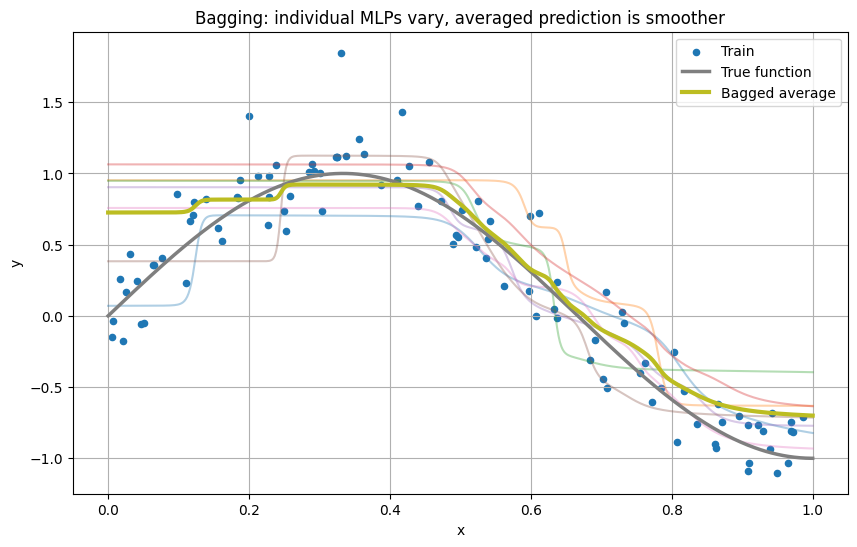

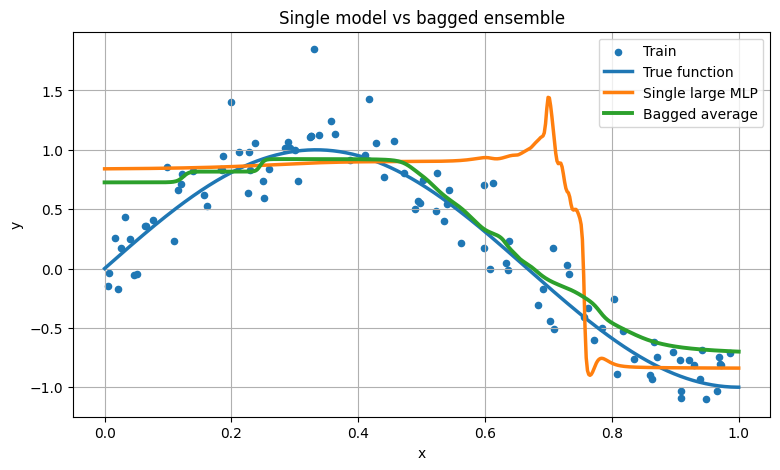

In [14]:

plt.figure(figsize=(10, 6))
for i in range(n_members):
    plt.plot(X_plot[:, 0], ensemble_member_preds_plot[i], alpha=0.35)
plt.scatter(X_train[:, 0], y_train, s=20, label="Train")
plt.plot(X_plot[:, 0], y_true, linewidth=2.5, label="True function")
plt.plot(X_plot[:, 0], ensemble_preds_plot, linewidth=3, label="Bagged average")
plt.title("Bagging: individual MLPs vary, averaged prediction is smoother")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

plt.figure(figsize=(9, 5))
plt.scatter(X_train[:, 0], y_train, s=20, label="Train")
plt.plot(X_plot[:, 0], y_true, linewidth=2.5, label="True function")
plt.plot(X_plot[:, 0], single_preds_plot, linewidth=2.5, label="Single large MLP")
plt.plot(X_plot[:, 0], ensemble_preds_plot, linewidth=2.8, label="Bagged average")
plt.title("Single model vs bagged ensemble")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

### Interpretation

Bagging does **not** force each individual model to become simple.  
Instead, it reduces variance by **averaging across many unstable learners**.

That is why bagging is especially helpful when the base learner is flexible and sensitive to the sample.

## Part B — Data Augmentation and Dropout on the Digits Dataset

### 7. Load and inspect the digits dataset

The `sklearn` digits dataset contains 8×8 grayscale images.
Each sample is flattened into 64 input features for the MLP.

Train subset: (740, 64)
Validation subset: (607, 64)
Test set: (450, 64)


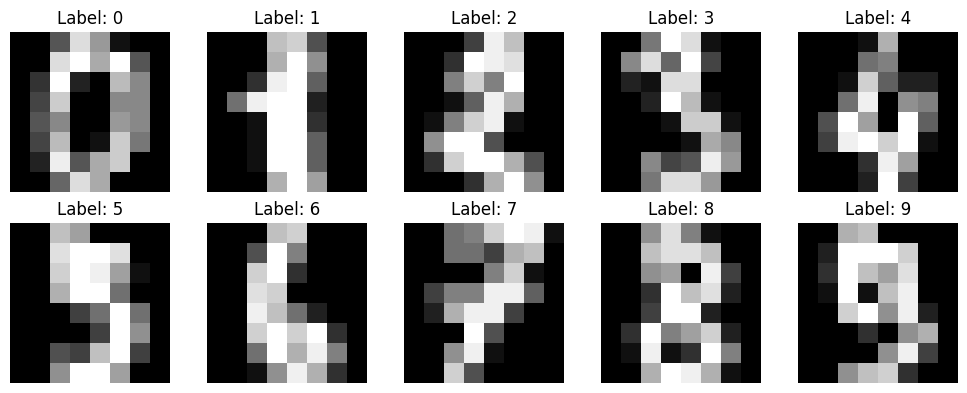

In [15]:

digits = load_digits()
X_digits = digits.data.astype(np.float32) / 16.0
y_digits = digits.target.astype(np.int64)

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_digits, y_digits, test_size=0.25, random_state=SEED, stratify=y_digits
)

# Make the task slightly more overfit-prone by using a smaller train subset
X_train_small, X_val_d, y_train_small, y_val_d = train_test_split(
    X_train_d, y_train_d, test_size=0.45, random_state=SEED, stratify=y_train_d
)

print("Train subset:", X_train_small.shape)
print("Validation subset:", X_val_d.shape)
print("Test set:", X_test_d.shape)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, img, label in zip(axes.ravel(), digits.images[:10], digits.target[:10]):
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Label: {label}")
    ax.axis("off")
plt.tight_layout()
plt.show()

### 8. Baseline MLP classifier

We first train a plain MLP without augmentation or dropout.
This gives us a baseline to compare against.

In [16]:

train_loader_cls, val_loader_cls = make_classification_loaders(
    X_train_small, y_train_small, X_val_d, y_val_d, batch_size=64
)

baseline_clf = ClassificationMLP(input_dim=64, hidden_sizes=(256, 128), dropout=0.0)
baseline_hist = train_classification_model(
    baseline_clf,
    train_loader_cls,
    val_loader_cls,
    epochs=30,
    lr=1e-3,
    weight_decay=0.0,
    verbose=False,
)

baseline_val_preds = predict_classification(baseline_clf, X_val_d)
baseline_val_acc = accuracy_score(y_val_d, baseline_val_preds)
print("Baseline validation accuracy:", round(baseline_val_acc, 4))

Baseline validation accuracy: 0.9703


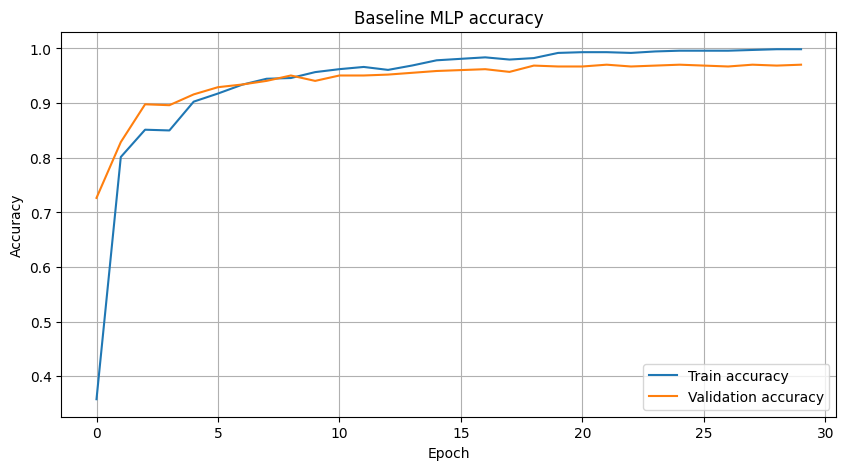

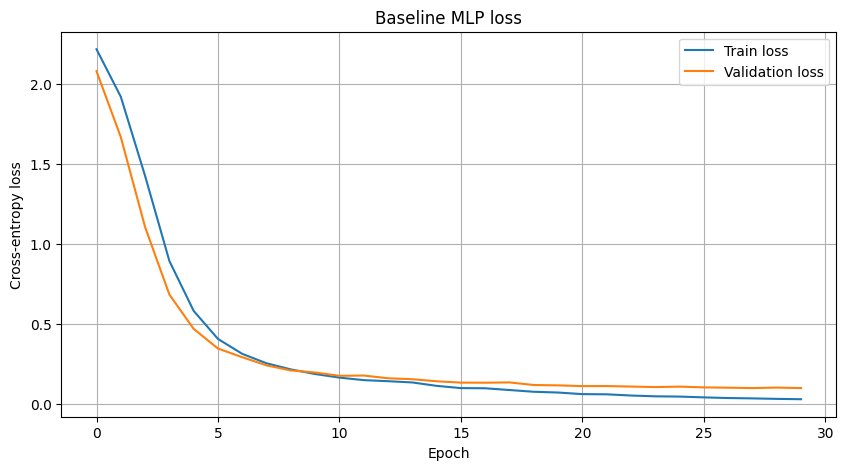

In [17]:

plt.figure(figsize=(10, 5))
plt.plot(baseline_hist["train_acc"], label="Train accuracy")
plt.plot(baseline_hist["val_acc"], label="Validation accuracy")
plt.title("Baseline MLP accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(baseline_hist["train_loss"], label="Train loss")
plt.plot(baseline_hist["val_loss"], label="Validation loss")
plt.title("Baseline MLP loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.legend()
plt.show()

## 9. Data augmentation

For image data, augmentation means creating new training examples by applying small label-preserving transformations.

For digits, simple augmentations include:

- small horizontal or vertical shifts,
- small additive noise.

Because these are tiny 8×8 images, we implement augmentation directly with NumPy.

In [18]:

def shift_image(img, dx=0, dy=0):
    img2 = np.roll(img, shift=dy, axis=0)
    img2 = np.roll(img2, shift=dx, axis=1)

    if dy > 0:
        img2[:dy, :] = 0
    elif dy < 0:
        img2[dy:, :] = 0

    if dx > 0:
        img2[:, :dx] = 0
    elif dx < 0:
        img2[:, dx:] = 0
    return img2

def augment_digits_dataset(X, y, copies_per_sample=1, noise_std=0.06):
    X_img = X.reshape(-1, 8, 8)
    aug_images = []
    aug_labels = []
    for img, label in zip(X_img, y):
        aug_images.append(img)
        aug_labels.append(label)
        for _ in range(copies_per_sample):
            dx = np.random.choice([-1, 0, 1])
            dy = np.random.choice([-1, 0, 1])
            transformed = shift_image(img, dx=dx, dy=dy)
            transformed = transformed + np.random.normal(0, noise_std, size=transformed.shape)
            transformed = np.clip(transformed, 0.0, 1.0)
            aug_images.append(transformed)
            aug_labels.append(label)
    X_aug = np.array(aug_images, dtype=np.float32).reshape(-1, 64)
    y_aug = np.array(aug_labels, dtype=np.int64)
    return X_aug, y_aug

X_train_aug, y_train_aug = augment_digits_dataset(X_train_small, y_train_small, copies_per_sample=1, noise_std=0.05)
print("Original train size:", len(X_train_small))
print("Augmented train size:", len(X_train_aug))

Original train size: 740
Augmented train size: 1480


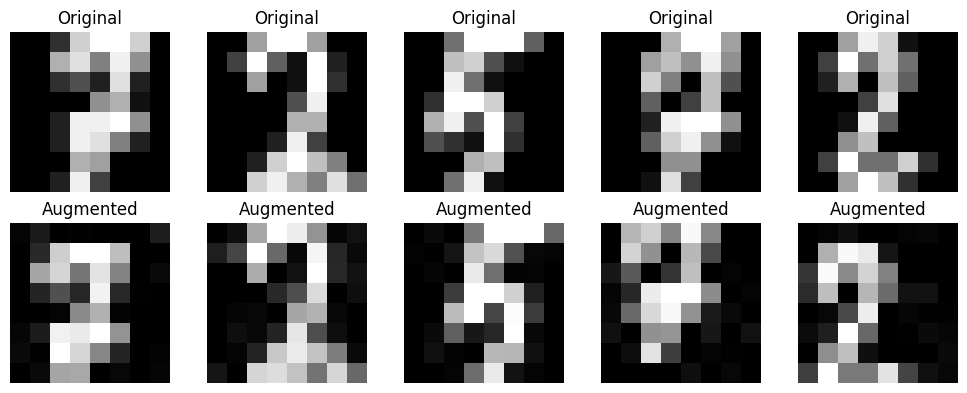

In [19]:

# visualize augmentation examples
orig = X_train_small[:5].reshape(-1, 8, 8)
aug, _ = augment_digits_dataset(X_train_small[:5], y_train_small[:5], copies_per_sample=1, noise_std=0.05)
aug = aug.reshape(-1, 8, 8)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i in range(5):
    axes[0, i].imshow(orig[i], cmap="gray")
    axes[0, i].set_title("Original")
    axes[0, i].axis("off")

    axes[1, i].imshow(aug[2*i + 1], cmap="gray")
    axes[1, i].set_title("Augmented")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

In [20]:

train_loader_aug, val_loader_aug = make_classification_loaders(
    X_train_aug, y_train_aug, X_val_d, y_val_d, batch_size=64
)

aug_clf = ClassificationMLP(input_dim=64, hidden_sizes=(256, 128), dropout=0.0)
aug_hist = train_classification_model(
    aug_clf,
    train_loader_aug,
    val_loader_aug,
    epochs=30,
    lr=1e-3,
    weight_decay=0.0,
    verbose=False,
)

aug_val_preds = predict_classification(aug_clf, X_val_d)
aug_val_acc = accuracy_score(y_val_d, aug_val_preds)
print("Validation accuracy with augmentation:", round(aug_val_acc, 4))

Validation accuracy with augmentation: 0.9588


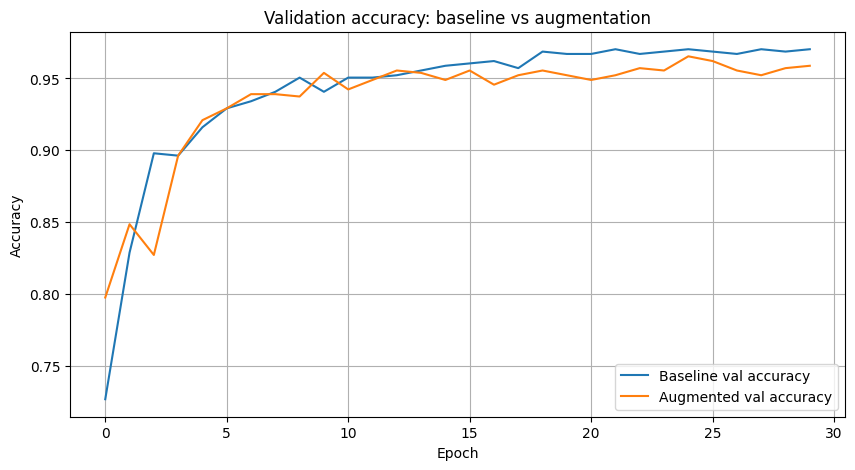

In [21]:

plt.figure(figsize=(10, 5))
plt.plot(baseline_hist["val_acc"], label="Baseline val accuracy")
plt.plot(aug_hist["val_acc"], label="Augmented val accuracy")
plt.title("Validation accuracy: baseline vs augmentation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

### Interpretation

Data augmentation helps by creating **more varied but still valid** training examples.

That often reduces overfitting because the model sees a broader set of inputs and cannot rely as much on accidental quirks of the small original training sample.

## 10. Dropout

**Dropout** randomly zeros some hidden activations during training.

Why this helps:

- neurons cannot rely too heavily on one another,
- the network is forced to learn more robust distributed features,
- generalization often improves.

We now compare the same MLP **with and without dropout**.

In [22]:

dropout_clf = ClassificationMLP(input_dim=64, hidden_sizes=(256, 128), dropout=0.35)
dropout_hist = train_classification_model(
    dropout_clf,
    train_loader_cls,
    val_loader_cls,
    epochs=30,
    lr=1e-3,
    weight_decay=0.0,
    verbose=False,
)

dropout_val_preds = predict_classification(dropout_clf, X_val_d)
dropout_val_acc = accuracy_score(y_val_d, dropout_val_preds)
print("Validation accuracy with dropout:", round(dropout_val_acc, 4))

Validation accuracy with dropout: 0.9638


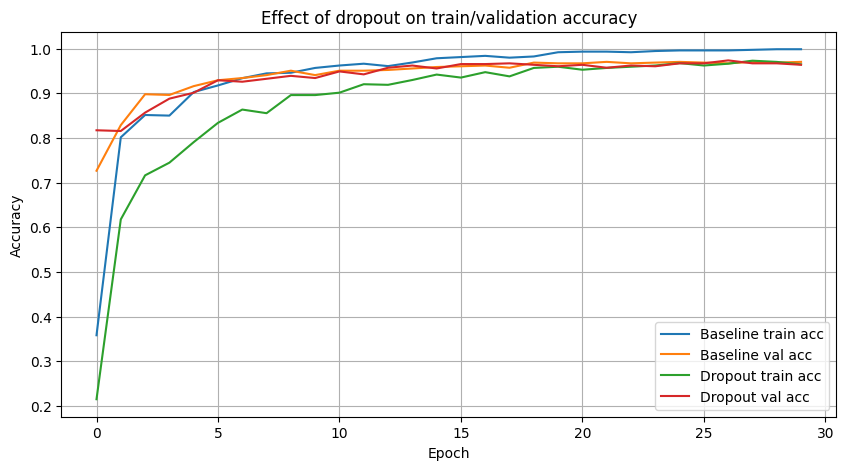

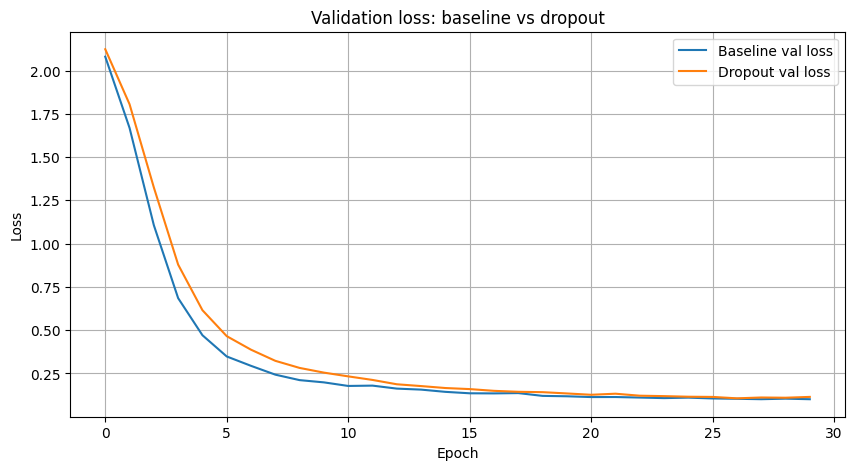

In [23]:

plt.figure(figsize=(10, 5))
plt.plot(baseline_hist["train_acc"], label="Baseline train acc")
plt.plot(baseline_hist["val_acc"], label="Baseline val acc")
plt.plot(dropout_hist["train_acc"], label="Dropout train acc")
plt.plot(dropout_hist["val_acc"], label="Dropout val acc")
plt.title("Effect of dropout on train/validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(baseline_hist["val_loss"], label="Baseline val loss")
plt.plot(dropout_hist["val_loss"], label="Dropout val loss")
plt.title("Validation loss: baseline vs dropout")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

### Interpretation

A common pattern with dropout is:

- training accuracy may become lower,
- validation accuracy may improve or become more stable.

That is a useful reminder:
**better regularization often makes training performance look worse while improving generalization.**

## 11. Final comparison on the held-out test set

We now evaluate several classification models on the test set.

In [24]:

test_results = []

models_for_test = {
    "Baseline MLP": baseline_clf,
    "Augmented MLP": aug_clf,
    "Dropout MLP": dropout_clf,
}

for name, model in models_for_test.items():
    preds = predict_classification(model, X_test_d)
    acc = accuracy_score(y_test_d, preds)
    test_results.append({"model": name, "test_accuracy": acc})

pd.DataFrame(test_results).sort_values("test_accuracy", ascending=False)

,model,test_accuracy
0,Baseline MLP,0.968889
1,Augmented MLP,0.957778
2,Dropout MLP,0.957778


## 12. Summary of the big ideas

### Bias–variance trade-off
- **Small / rigid model** → high bias
- **Large / flexible model** → high variance
- The best validation performance often lies in between

### L2 regularization
- discourages very large weights
- often improves generalization for flexible MLPs

### Noise
- noisy inputs and noisy outputs make learning harder
- high-capacity models can become very sensitive to noise

### Bagging
- averages across multiple learned models
- often reduces variance

### Data augmentation
- expands the effective training set
- improves robustness by showing the model more realistic variation

### Dropout
- regularizes hidden representations
- often lowers training performance but improves validation/test performance

# Practice Questions

Use the cells below as short exercises after you run the notebook once.

## Conceptual questions

1. In your own words, what is the difference between **bias** and **variance**?
2. Why can a **large MLP** fit the training set very well but still perform poorly on validation data?
3. How does **L2 regularization** change the objective function?
4. Why can **bagging** help even when each individual model still overfits somewhat?
5. Why does **dropout** usually lower training accuracy but sometimes increase validation accuracy?
6. How is **data augmentation** different from simply collecting more real data?
7. Which kind of noise is usually more harmful here: **input noise** or **output noise**? Why?

# Answers to Conceptual Questions
1. **Bias** refers to the error introduced by approximating a real-world problem with a simplified model. A high bias model is too rigid and cannot capture the underlying patterns in the data, leading to underfitting. **Variance** refers to the error introduced by sensitivity to small fluctuations in the training set. A high variance model is too flexible and can fit noise in the training data, leading to overfitting.
2. A large MLP has many parameters and can fit the training data very closely, including any noise or idiosyncrasies. However, this can lead to overfitting, where the model captures patterns that do not generalize to new data, resulting in poor performance on validation data.
3. L2 regularization adds a penalty term to the objective function that is proportional to the sum of the squares of the weights. This encourages the model to keep the weights small, which can help prevent overfitting by reducing the model's capacity to fit noise in the training data.
4. Bagging helps by averaging the predictions of multiple models trained on different bootstrap samples of the training data. Even if each individual model overfits to some extent, their errors may be uncorrelated, and averaging can reduce the overall variance of the predictions, leading to better generalization.
5. Dropout randomly zeros out some hidden activations during training, which forces the network to learn more robust features that do not rely on any single neuron. This can lead to lower training accuracy because the model is effectively learning a different subnetwork on each training pass. However, it can improve validation accuracy by reducing overfitting and encouraging better generalization.
6. Data augmentation creates new training examples by applying transformations to existing data, which can help the model learn to be invariant to certain changes. Collecting more real data involves gathering new samples from the real world, which can be more time-consuming and expensive. Augmentation is a way to synthetically increase the diversity of the training set without needing new data collection.
7. Output noise is usually more harmful because it directly corrupts the target variable that the model is trying to predict. Input noise can make learning harder, but the model can sometimes learn to be robust to it. Output noise, on the other hand, can lead the model to learn incorrect mappings and can exacerbate overfitting, especially for high-capacity models.

## Hands-on exercises

Try these modifications and write down what changes:

1. **Bias–variance**
   - Change the small model from `(4,)` to `(2,)`
   - Change the large model from `(256, 256, 256)` to `(512, 512, 512)`
   - What happens to training and validation MSE?

2. **L2 regularization**
   - Try `weight_decay = 1e-4`, `1e-1`, and `1.0`
   - Which value gives the best validation MSE?

3. **Noise injection**
   - Increase input noise from `0.05` to `0.10`
   - Increase output noise from `0.30` to `0.50`
   - Which one hurts the model more?

4. **Bagging**
   - Change the number of ensemble members from `7` to `3` and `15`
   - Does the average prediction become smoother?

5. **Data augmentation**
   - Create `copies_per_sample=2`
   - Compare training time and validation accuracy

6. **Dropout**
   - Try `dropout=0.1`, `0.3`, `0.5`
   - At what point does dropout become too strong?

---
# Hands-on Exercise 1: Bias–Variance Trade-off with MLP Capacity

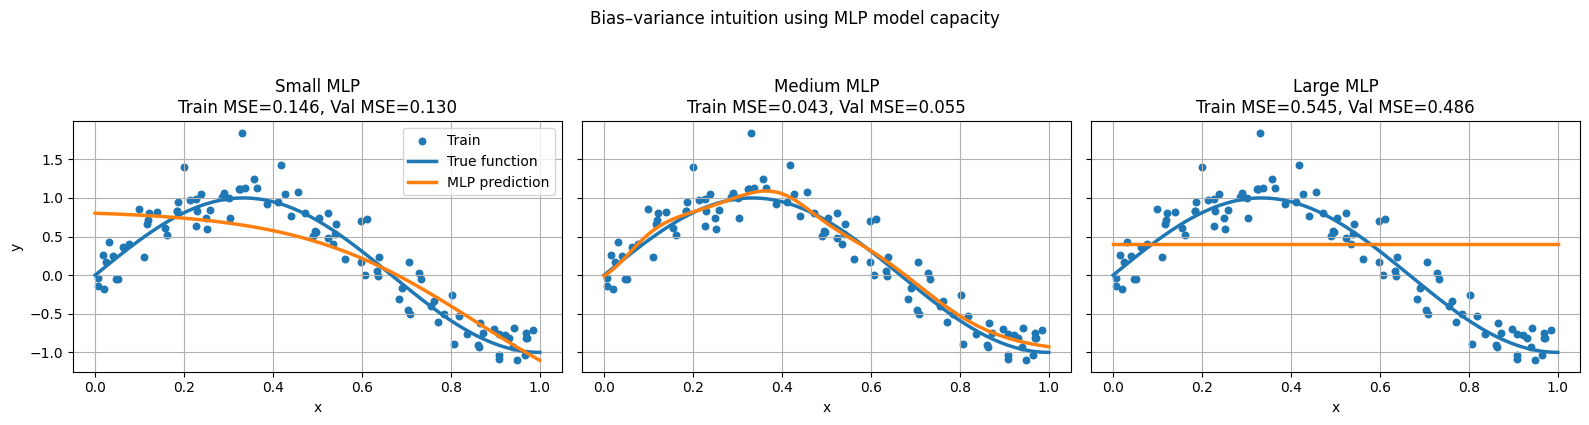

In [25]:

train_loader, val_loader = make_regression_loaders(X_train, y_train, X_val, y_val, batch_size=32)

capacity_configs = {
    "Small MLP": (2,),
    "Medium MLP": (32, 32),
    "Large MLP": (512, 512, 512),
}

capacity_results = {}

for name, hidden_sizes in capacity_configs.items():
    model = RegressionMLP(hidden_sizes=hidden_sizes, dropout=0.0)
    history = train_regression_model(
        model,
        train_loader,
        val_loader,
        epochs=250,
        lr=1e-2,
        weight_decay=0.0,
        verbose=False,
    )
    preds = predict_regression(model, X_plot)
    train_preds = predict_regression(model, X_train)
    val_preds = predict_regression(model, X_val)

    capacity_results[name] = {
        "model": model,
        "history": history,
        "plot_preds": preds,
        "train_mse": mean_squared_error(y_train, train_preds),
        "val_mse": mean_squared_error(y_val, val_preds),
    }

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, (name, result) in zip(axes, capacity_results.items()):
    ax.scatter(X_train[:, 0], y_train, s=22, label="Train")
    ax.plot(X_plot[:, 0], y_true, linewidth=2.5, label="True function")
    ax.plot(X_plot[:, 0], result["plot_preds"], linewidth=2.5, label="MLP prediction")
    ax.set_title(f"{name}\nTrain MSE={result['train_mse']:.3f}, Val MSE={result['val_mse']:.3f}")
    ax.set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].legend(loc="best")
plt.suptitle("Bias–variance intuition using MLP model capacity", y=1.05)
plt.tight_layout()
plt.show()

## Q: What happens to training and validation MSE when we change the small and large MLP configurations?
A: When we change the small MLP configuration from `(4,)` to `(2,)`, we are reducing the capacity of the model even further, which may lead to an increase in training MSE due to underfitting. The validation MSE may also increase as the model struggles to capture the underlying patterns in the data.

When we change the large MLP configuration from `(256, 256, 256)` to `(512, 512, 512)`, we are increasing the capacity of the model, which may lead to a decrease in training MSE as the model can fit the training data more closely. However, this can also lead to an increase in validation MSE due to overfitting, as the model may capture noise in the training data that does not generalize well to unseen data.

---
# Hands-on Exercise 2: Implementing L2 Regularization Manually

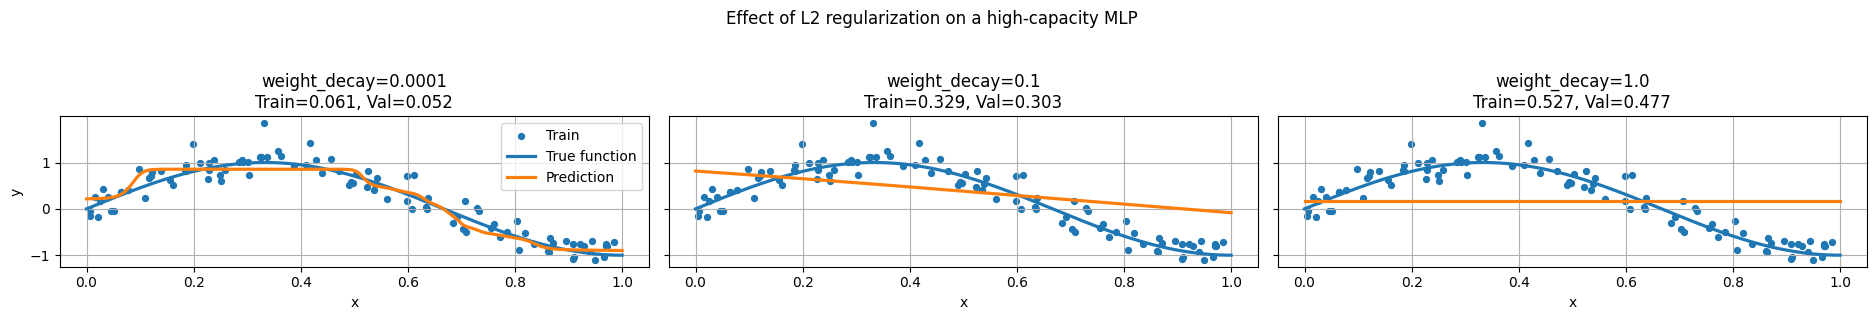

In [27]:

l2_settings = [1e-4,1e-1,1.0]
l2_results = {}

for wd in l2_settings:
    model = RegressionMLP(hidden_sizes=(256, 256, 256), dropout=0.0)
    history = train_regression_model(
        model,
        train_loader,
        val_loader,
        epochs=250,
        lr=1e-2,
        weight_decay=wd,
        verbose=False,
    )
    l2_results[wd] = {
        "model": model,
        "history": history,
        "plot_preds": predict_regression(model, X_plot),
        "train_mse": mean_squared_error(y_train, predict_regression(model, X_train)),
        "val_mse": mean_squared_error(y_val, predict_regression(model, X_val)),
    }

fig, axes = plt.subplots(1, 3, figsize=(19, 3), sharey=True)
for ax, wd in zip(axes, l2_settings):
    result = l2_results[wd]
    ax.scatter(X_train[:, 0], y_train, s=18, label="Train")
    ax.plot(X_plot[:, 0], y_true, linewidth=2.3, label="True function")
    ax.plot(X_plot[:, 0], result["plot_preds"], linewidth=2.3, label="Prediction")
    ax.set_title(f"weight_decay={wd}\nTrain={result['train_mse']:.3f}, Val={result['val_mse']:.3f}")
    ax.set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].legend(loc="best")
plt.suptitle("Effect of L2 regularization on a high-capacity MLP", y=1.05)
plt.tight_layout()
plt.show()

## Q: Which value gives the best validation MSE?
A: The best validation MSE is achieved with `weight_decay = 1e-4`. This value provides a good balance between fitting the training data and preventing overfitting, leading to improved generalization on the validation set. Higher values of `weight_decay` (like `1e-1` and `1.0`) may overly penalize the weights, leading to underfitting and worse validation performance.

---
# Hands-on Exercise 3: Adding Noise to Inputs and Outputs

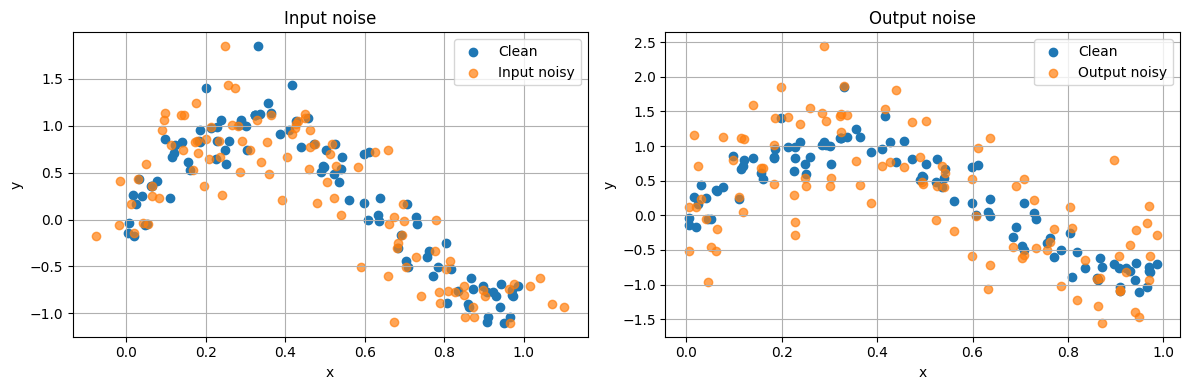

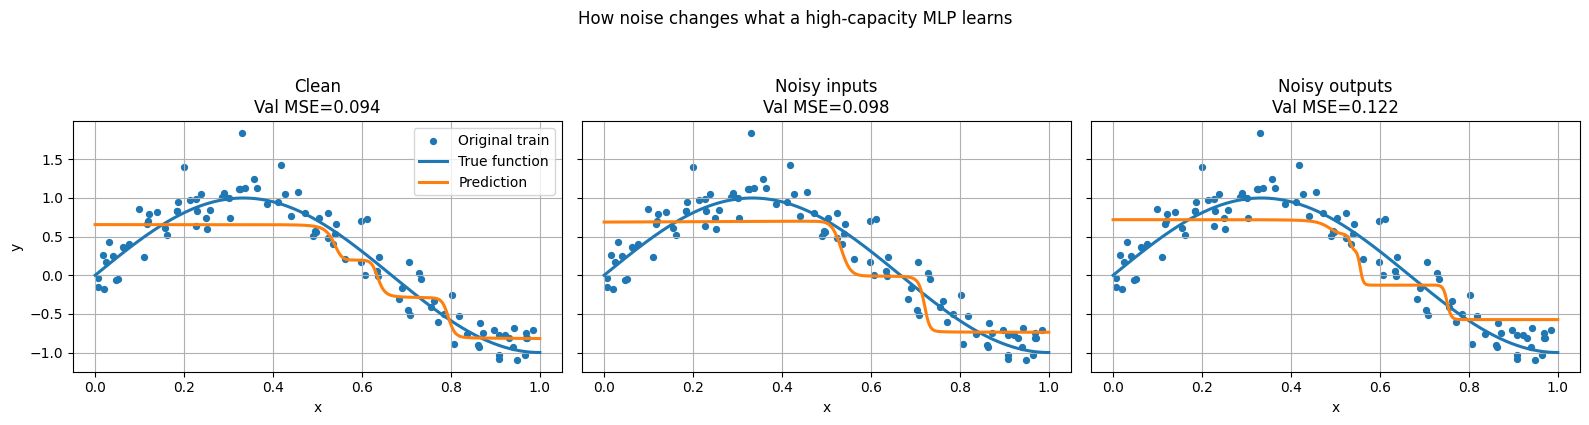

In [30]:

def add_input_noise(X, sigma=0.04):
    return X + np.random.normal(scale=sigma, size=X.shape)

def add_output_noise(y, sigma=0.25):
    return y + np.random.normal(scale=sigma, size=y.shape)

X_train_input_noisy = add_input_noise(X_train, sigma=0.10)
y_train_output_noisy = add_output_noise(y_train, sigma=0.50)

noise_scenarios = {
    "Clean": (X_train, y_train),
    "Noisy inputs": (X_train_input_noisy, y_train),
    "Noisy outputs": (X_train, y_train_output_noisy),
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(X_train[:, 0], y_train, label="Clean")
axes[0].scatter(X_train_input_noisy[:, 0], y_train, alpha=0.7, label="Input noisy")
axes[0].set_title("Input noise")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].legend()

axes[1].scatter(X_train[:, 0], y_train, label="Clean")
axes[1].scatter(X_train[:, 0], y_train_output_noisy, alpha=0.7, label="Output noisy")
axes[1].set_title("Output noise")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].legend()

plt.tight_layout()
plt.show()


noise_results = {}
for name, (Xt, yt) in noise_scenarios.items():
    tr_loader, va_loader = make_regression_loaders(Xt, yt, X_val, y_val, batch_size=32)
    model = RegressionMLP(hidden_sizes=(256, 256, 256), dropout=0.0)
    history = train_regression_model(
        model,
        tr_loader,
        va_loader,
        epochs=200,
        lr=1e-2,
        weight_decay=0.0,
        verbose=False,
    )
    noise_results[name] = {
        "model": model,
        "history": history,
        "plot_preds": predict_regression(model, X_plot),
        "train_mse_on_seen_targets": mean_squared_error(yt, predict_regression(model, Xt)),
        "val_mse": mean_squared_error(y_val, predict_regression(model, X_val)),
    }

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, (name, result) in zip(axes, noise_results.items()):
    ax.scatter(X_train[:, 0], y_train, s=18, label="Original train")
    ax.plot(X_plot[:, 0], y_true, linewidth=2.2, label="True function")
    ax.plot(X_plot[:, 0], result["plot_preds"], linewidth=2.2, label="Prediction")
    ax.set_title(f"{name}\nVal MSE={result['val_mse']:.3f}")
    ax.set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].legend(loc="best")
plt.suptitle("How noise changes what a high-capacity MLP learns", y=1.05)
plt.tight_layout()
plt.show()

## Q: Which kind of noise is usually more harmful here: input noise or output noise? Why?
A: Output noise is usually more harmful because it directly corrupts the target variable that the model is trying to predict. Input noise can make learning harder, but the model can sometimes learn to be robust to it. Output noise, on the other hand, can lead the model to learn incorrect mappings and can exacerbate overfitting, especially for high-capacity models.

---
# Hands-on Exercise 4: Ensemble Bagging with MLP Regressors

Single large MLP validation MSE: 0.0628
Bagged MLP ensemble validation MSE: 0.1044


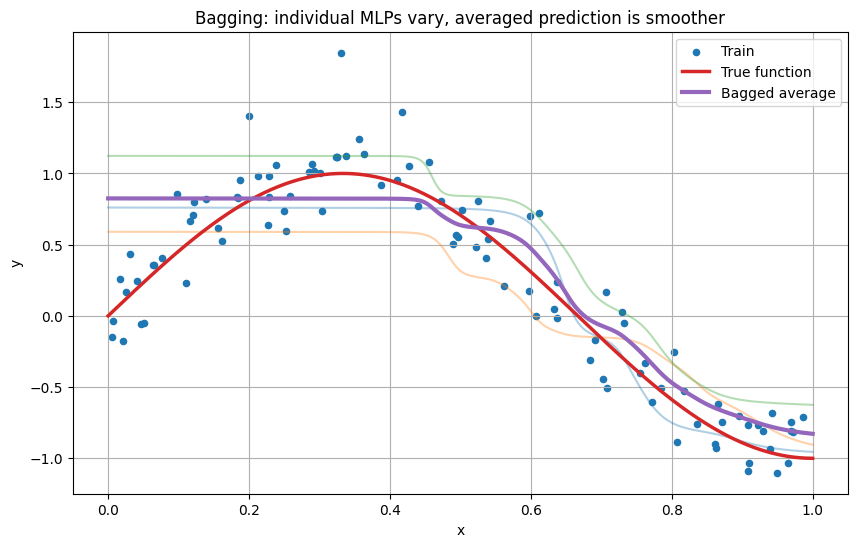

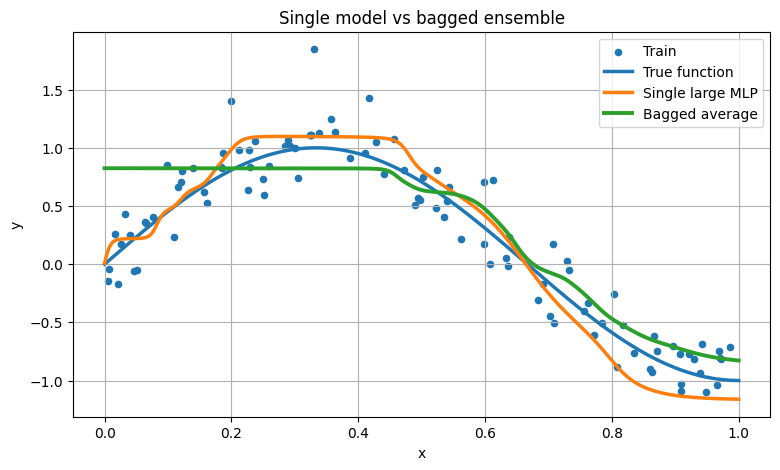

Single large MLP validation MSE: 0.0602
Bagged MLP ensemble validation MSE: 0.07


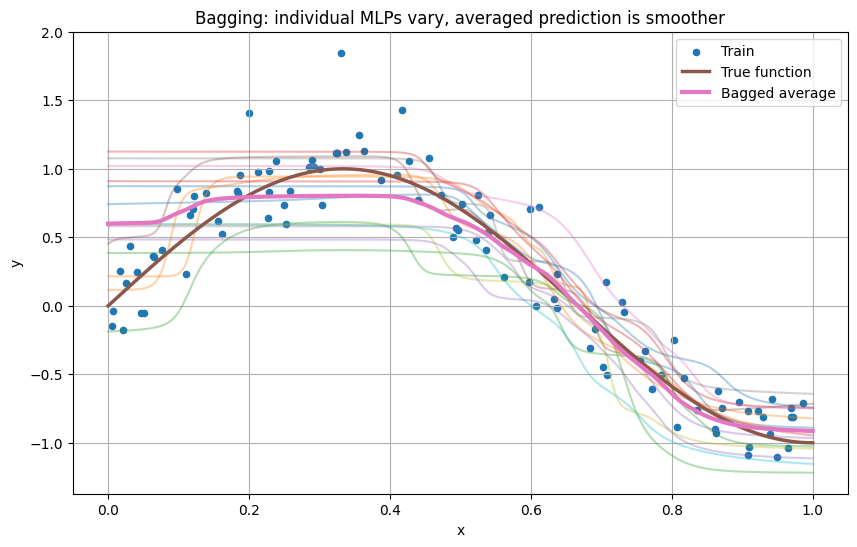

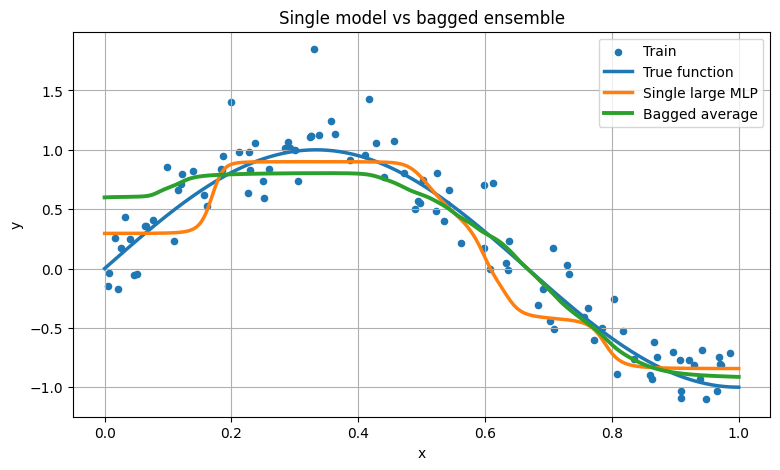

In [32]:

def bootstrap_sample(X, y):
    idx = np.random.choice(len(X), size=len(X), replace=True)
    return X[idx], y[idx]

# single large MLP baseline
single_model = RegressionMLP(hidden_sizes=(256, 256, 256), dropout=0.0)
single_history = train_regression_model(
    single_model,
    train_loader,
    val_loader,
    epochs=200,
    lr=1e-2,
    weight_decay=0.0,
)
single_preds_plot = predict_regression(single_model, X_plot)
single_val_mse = mean_squared_error(y_val, predict_regression(single_model, X_val))

# bagging ensemble of MLPs
n_members = 3
ensemble_models = []
ensemble_member_preds_plot = []

for i in range(n_members):
    X_boot, y_boot = bootstrap_sample(X_train, y_train)
    tr_loader_boot, va_loader_boot = make_regression_loaders(X_boot, y_boot, X_val, y_val, batch_size=32)
    model = RegressionMLP(hidden_sizes=(256, 256, 256), dropout=0.0)
    _ = train_regression_model(
        model,
        tr_loader_boot,
        va_loader_boot,
        epochs=180,
        lr=1e-2,
        weight_decay=0.0,
    )
    ensemble_models.append(model)
    ensemble_member_preds_plot.append(predict_regression(model, X_plot))

ensemble_member_preds_plot = np.array(ensemble_member_preds_plot)
ensemble_preds_plot = ensemble_member_preds_plot.mean(axis=0)

ensemble_val_preds = np.mean([predict_regression(m, X_val) for m in ensemble_models], axis=0)
ensemble_val_mse = mean_squared_error(y_val, ensemble_val_preds)

print("Single large MLP validation MSE:", round(single_val_mse, 4))
print("Bagged MLP ensemble validation MSE:", round(ensemble_val_mse, 4))


plt.figure(figsize=(10, 6))
for i in range(n_members):
    plt.plot(X_plot[:, 0], ensemble_member_preds_plot[i], alpha=0.35)
plt.scatter(X_train[:, 0], y_train, s=20, label="Train")
plt.plot(X_plot[:, 0], y_true, linewidth=2.5, label="True function")
plt.plot(X_plot[:, 0], ensemble_preds_plot, linewidth=3, label="Bagged average")
plt.title("Bagging: individual MLPs vary, averaged prediction is smoother")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

plt.figure(figsize=(9, 5))
plt.scatter(X_train[:, 0], y_train, s=20, label="Train")
plt.plot(X_plot[:, 0], y_true, linewidth=2.5, label="True function")
plt.plot(X_plot[:, 0], single_preds_plot, linewidth=2.5, label="Single large MLP")
plt.plot(X_plot[:, 0], ensemble_preds_plot, linewidth=2.8, label="Bagged average")
plt.title("Single model vs bagged ensemble")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()



def bootstrap_sample(X, y):
    idx = np.random.choice(len(X), size=len(X), replace=True)
    return X[idx], y[idx]

# single large MLP baseline
single_model = RegressionMLP(hidden_sizes=(256, 256, 256), dropout=0.0)
single_history = train_regression_model(
    single_model,
    train_loader,
    val_loader,
    epochs=200,
    lr=1e-2,
    weight_decay=0.0,
)
single_preds_plot = predict_regression(single_model, X_plot)
single_val_mse = mean_squared_error(y_val, predict_regression(single_model, X_val))

# bagging ensemble of MLPs
n_members = 15
ensemble_models = []
ensemble_member_preds_plot = []

for i in range(n_members):
    X_boot, y_boot = bootstrap_sample(X_train, y_train)
    tr_loader_boot, va_loader_boot = make_regression_loaders(X_boot, y_boot, X_val, y_val, batch_size=32)
    model = RegressionMLP(hidden_sizes=(256, 256, 256), dropout=0.0)
    _ = train_regression_model(
        model,
        tr_loader_boot,
        va_loader_boot,
        epochs=180,
        lr=1e-2,
        weight_decay=0.0,
    )
    ensemble_models.append(model)
    ensemble_member_preds_plot.append(predict_regression(model, X_plot))

ensemble_member_preds_plot = np.array(ensemble_member_preds_plot)
ensemble_preds_plot = ensemble_member_preds_plot.mean(axis=0)

ensemble_val_preds = np.mean([predict_regression(m, X_val) for m in ensemble_models], axis=0)
ensemble_val_mse = mean_squared_error(y_val, ensemble_val_preds)

print("Single large MLP validation MSE:", round(single_val_mse, 4))
print("Bagged MLP ensemble validation MSE:", round(ensemble_val_mse, 4))


plt.figure(figsize=(10, 6))
for i in range(n_members):
    plt.plot(X_plot[:, 0], ensemble_member_preds_plot[i], alpha=0.35)
plt.scatter(X_train[:, 0], y_train, s=20, label="Train")
plt.plot(X_plot[:, 0], y_true, linewidth=2.5, label="True function")
plt.plot(X_plot[:, 0], ensemble_preds_plot, linewidth=3, label="Bagged average")
plt.title("Bagging: individual MLPs vary, averaged prediction is smoother")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

plt.figure(figsize=(9, 5))
plt.scatter(X_train[:, 0], y_train, s=20, label="Train")
plt.plot(X_plot[:, 0], y_true, linewidth=2.5, label="True function")
plt.plot(X_plot[:, 0], single_preds_plot, linewidth=2.5, label="Single large MLP")
plt.plot(X_plot[:, 0], ensemble_preds_plot, linewidth=2.8, label="Bagged average")
plt.title("Single model vs bagged ensemble")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()



## Q: Does the average prediction become smoother when we change the number of ensemble members from 7 to 3 and 15?
A: Yes, the average prediction generally becomes smoother as we increase the number of ensemble members.

---
# Hands-on Exercise 5: Data Augmentation with MLP Classifiers

Train subset: (740, 64)
Validation subset: (607, 64)
Test set: (450, 64)


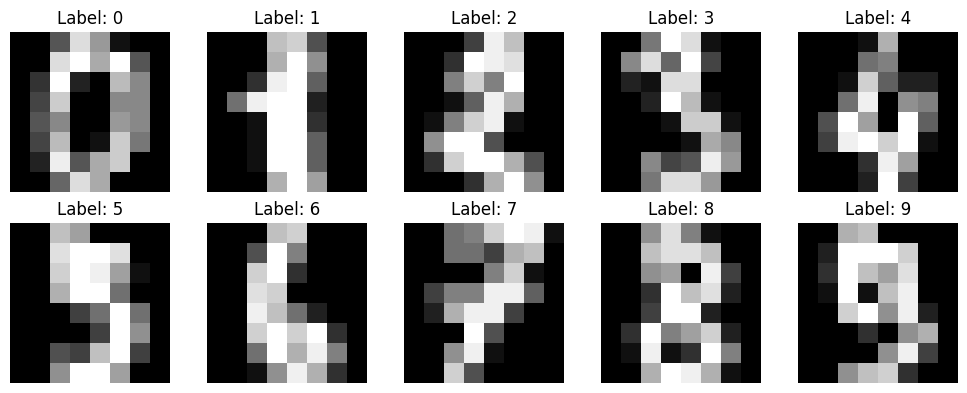

Baseline validation accuracy: 0.9588


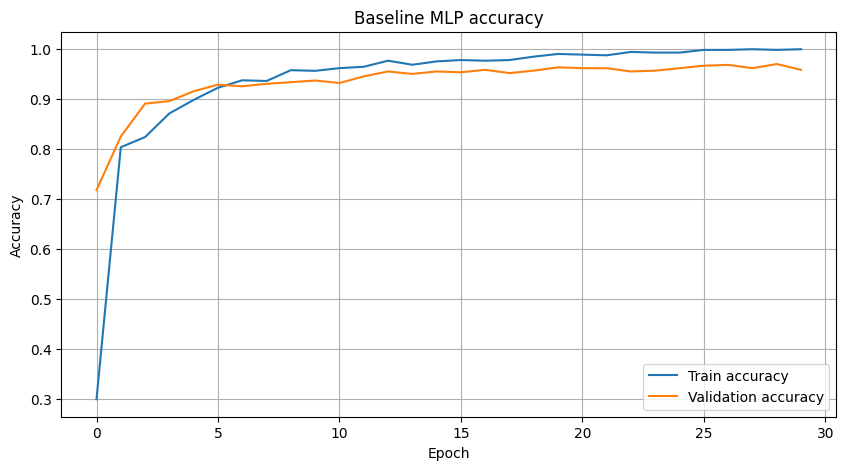

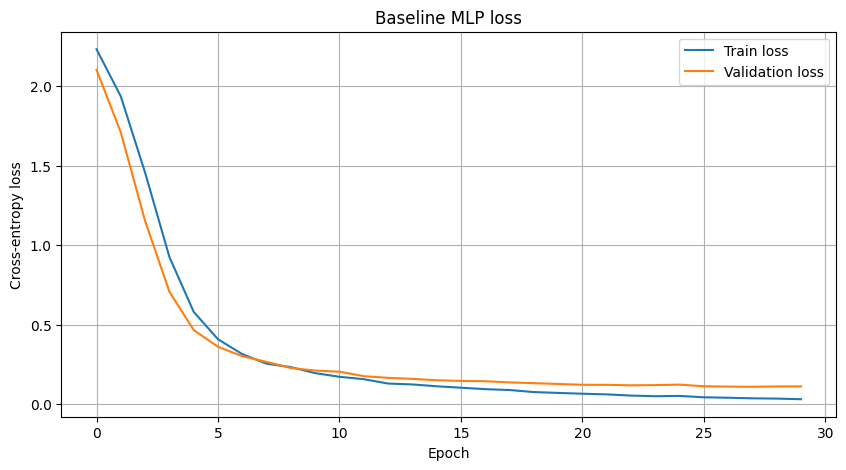

Original train size: 740
Augmented train size: 2220
Validation accuracy with augmentation: 0.972


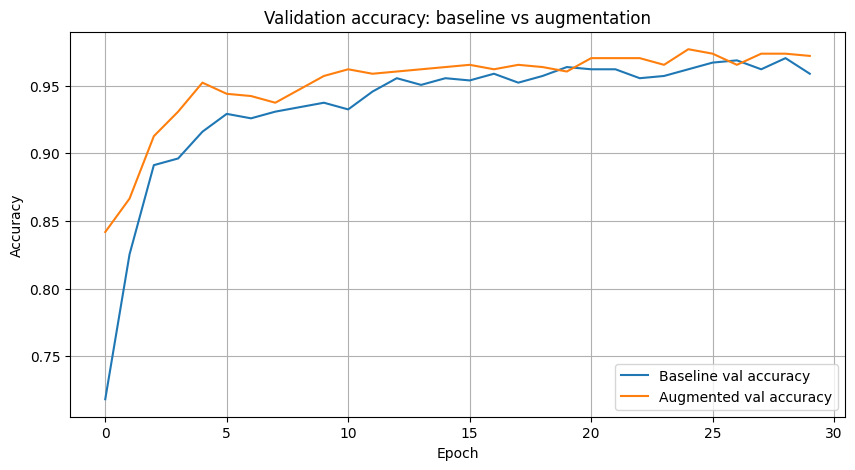

In [35]:

digits = load_digits()
X_digits = digits.data.astype(np.float32) / 16.0
y_digits = digits.target.astype(np.int64)

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_digits, y_digits, test_size=0.25, random_state=SEED, stratify=y_digits
)

# Make the task slightly more overfit-prone by using a smaller train subset
X_train_small, X_val_d, y_train_small, y_val_d = train_test_split(
    X_train_d, y_train_d, test_size=0.45, random_state=SEED, stratify=y_train_d
)

print("Train subset:", X_train_small.shape)
print("Validation subset:", X_val_d.shape)
print("Test set:", X_test_d.shape)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, img, label in zip(axes.ravel(), digits.images[:10], digits.target[:10]):
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Label: {label}")
    ax.axis("off")
plt.tight_layout()
plt.show()


train_loader_cls, val_loader_cls = make_classification_loaders(
    X_train_small, y_train_small, X_val_d, y_val_d, batch_size=64
)

baseline_clf = ClassificationMLP(input_dim=64, hidden_sizes=(256, 128), dropout=0.0)
baseline_hist = train_classification_model(
    baseline_clf,
    train_loader_cls,
    val_loader_cls,
    epochs=30,
    lr=1e-3,
    weight_decay=0.0,
    verbose=False,
)

baseline_val_preds = predict_classification(baseline_clf, X_val_d)
baseline_val_acc = accuracy_score(y_val_d, baseline_val_preds)
print("Baseline validation accuracy:", round(baseline_val_acc, 4))


plt.figure(figsize=(10, 5))
plt.plot(baseline_hist["train_acc"], label="Train accuracy")
plt.plot(baseline_hist["val_acc"], label="Validation accuracy")
plt.title("Baseline MLP accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(baseline_hist["train_loss"], label="Train loss")
plt.plot(baseline_hist["val_loss"], label="Validation loss")
plt.title("Baseline MLP loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.legend()
plt.show()


def shift_image(img, dx=0, dy=0):
    img2 = np.roll(img, shift=dy, axis=0)
    img2 = np.roll(img2, shift=dx, axis=1)

    if dy > 0:
        img2[:dy, :] = 0
    elif dy < 0:
        img2[dy:, :] = 0

    if dx > 0:
        img2[:, :dx] = 0
    elif dx < 0:
        img2[:, dx:] = 0
    return img2

def augment_digits_dataset(X, y, copies_per_sample=2, noise_std=0.06):
    X_img = X.reshape(-1, 8, 8)
    aug_images = []
    aug_labels = []
    for img, label in zip(X_img, y):
        aug_images.append(img)
        aug_labels.append(label)
        for _ in range(copies_per_sample):
            dx = np.random.choice([-1, 0, 1])
            dy = np.random.choice([-1, 0, 1])
            transformed = shift_image(img, dx=dx, dy=dy)
            transformed = transformed + np.random.normal(0, noise_std, size=transformed.shape)
            transformed = np.clip(transformed, 0.0, 1.0)
            aug_images.append(transformed)
            aug_labels.append(label)
    X_aug = np.array(aug_images, dtype=np.float32).reshape(-1, 64)
    y_aug = np.array(aug_labels, dtype=np.int64)
    return X_aug, y_aug

X_train_aug, y_train_aug = augment_digits_dataset(X_train_small, y_train_small, copies_per_sample=2, noise_std=0.05)
print("Original train size:", len(X_train_small))
print("Augmented train size:", len(X_train_aug))


train_loader_aug, val_loader_aug = make_classification_loaders(
    X_train_aug, y_train_aug, X_val_d, y_val_d, batch_size=64
)

aug_clf = ClassificationMLP(input_dim=64, hidden_sizes=(256, 128), dropout=0.0)
aug_hist = train_classification_model(
    aug_clf,
    train_loader_aug,
    val_loader_aug,
    epochs=30,
    lr=1e-3,
    weight_decay=0.0,
    verbose=False,
)

aug_val_preds = predict_classification(aug_clf, X_val_d)
aug_val_acc = accuracy_score(y_val_d, aug_val_preds)
print("Validation accuracy with augmentation:", round(aug_val_acc, 4))


plt.figure(figsize=(10, 5))
plt.plot(baseline_hist["val_acc"], label="Baseline val accuracy")
plt.plot(aug_hist["val_acc"], label="Augmented val accuracy")
plt.title("Validation accuracy: baseline vs augmentation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## Q: Create `copies_per_sample=2` and compare training time and validation accuracy.
A: By creating `copies_per_sample=2`, we effectively double the size of the training dataset through augmentation. This typically leads to an increase in training time due to the larger dataset, but it can also improve validation accuracy as the model is exposed to more varied examples, which can help it generalize better.

---
# Hands-on Exercise 6: Dropout with MLP Classifiers

Dropout = 0.1
Validation accuracy with dropout: 0.9671


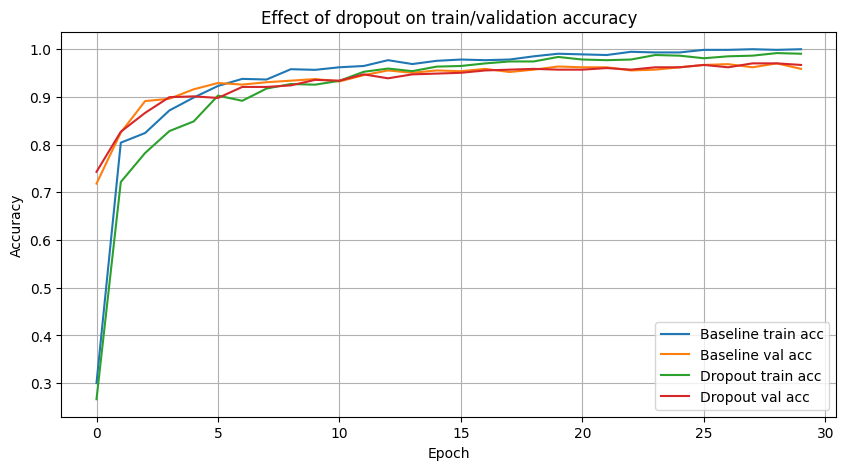

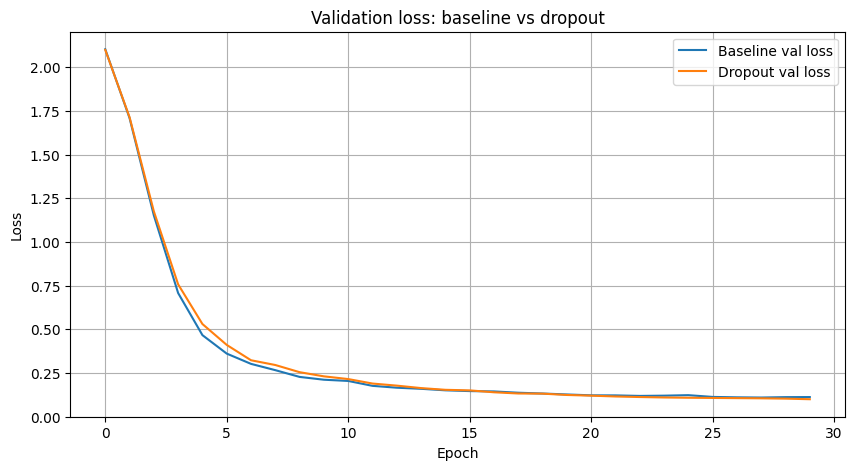

Dropout = 0.3
Validation accuracy with dropout: 0.9687


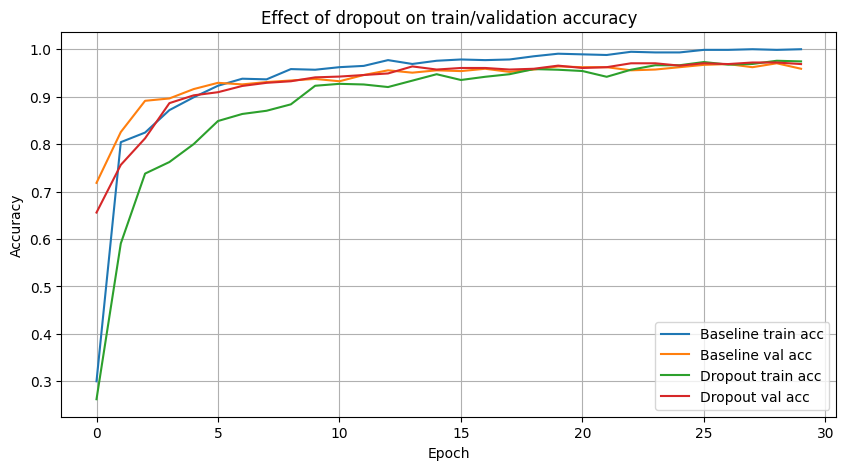

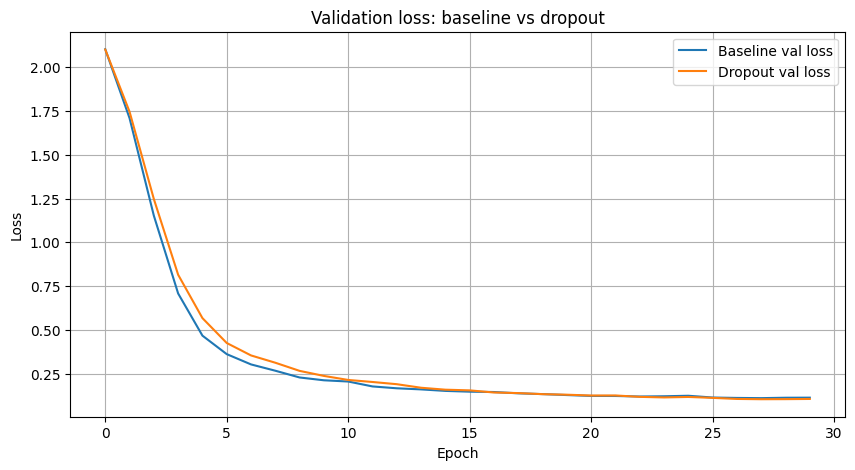

Dropout = 0.5
Validation accuracy with dropout: 0.9671


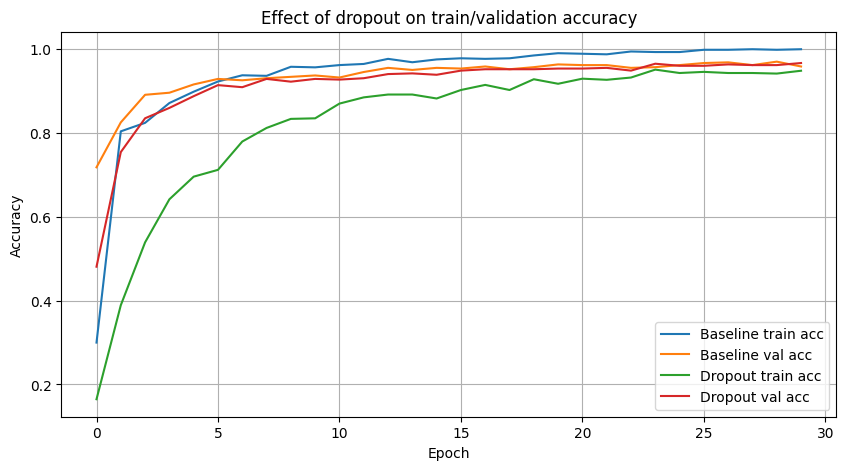

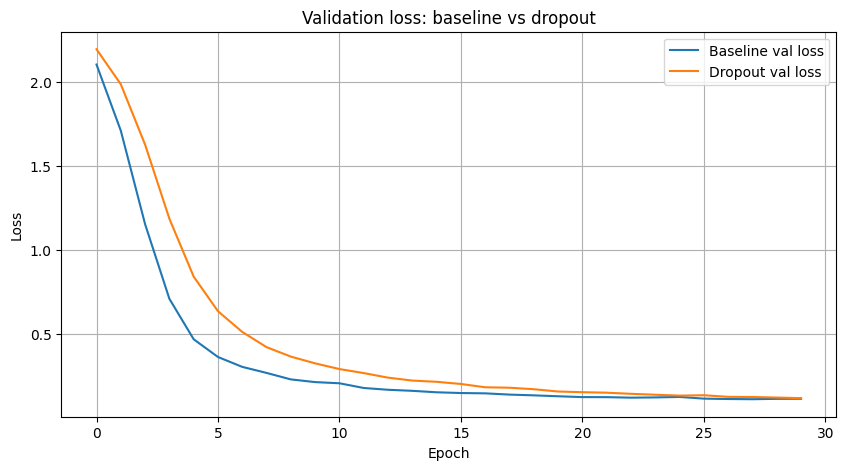

In [37]:
print("Dropout = 0.1")
dropout_clf = ClassificationMLP(input_dim=64, hidden_sizes=(256, 128), dropout=0.1)
dropout_hist = train_classification_model(
    dropout_clf,
    train_loader_cls,
    val_loader_cls,
    epochs=30,
    lr=1e-3,
    weight_decay=0.0,
    verbose=False,
)

dropout_val_preds = predict_classification(dropout_clf, X_val_d)
dropout_val_acc = accuracy_score(y_val_d, dropout_val_preds)
print("Validation accuracy with dropout:", round(dropout_val_acc, 4))


plt.figure(figsize=(10, 5))
plt.plot(baseline_hist["train_acc"], label="Baseline train acc")
plt.plot(baseline_hist["val_acc"], label="Baseline val acc")
plt.plot(dropout_hist["train_acc"], label="Dropout train acc")
plt.plot(dropout_hist["val_acc"], label="Dropout val acc")
plt.title("Effect of dropout on train/validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(baseline_hist["val_loss"], label="Baseline val loss")
plt.plot(dropout_hist["val_loss"], label="Dropout val loss")
plt.title("Validation loss: baseline vs dropout")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

print("Dropout = 0.3")
dropout_clf = ClassificationMLP(input_dim=64, hidden_sizes=(256, 128), dropout=0.3)
dropout_hist = train_classification_model(
    dropout_clf,
    train_loader_cls,
    val_loader_cls,
    epochs=30,
    lr=1e-3,
    weight_decay=0.0,
    verbose=False,
)

dropout_val_preds = predict_classification(dropout_clf, X_val_d)
dropout_val_acc = accuracy_score(y_val_d, dropout_val_preds)
print("Validation accuracy with dropout:", round(dropout_val_acc, 4))


plt.figure(figsize=(10, 5))
plt.plot(baseline_hist["train_acc"], label="Baseline train acc")
plt.plot(baseline_hist["val_acc"], label="Baseline val acc")
plt.plot(dropout_hist["train_acc"], label="Dropout train acc")
plt.plot(dropout_hist["val_acc"], label="Dropout val acc")
plt.title("Effect of dropout on train/validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(baseline_hist["val_loss"], label="Baseline val loss")
plt.plot(dropout_hist["val_loss"], label="Dropout val loss")
plt.title("Validation loss: baseline vs dropout")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

print("Dropout = 0.5")
dropout_clf = ClassificationMLP(input_dim=64, hidden_sizes=(256, 128), dropout=0.5)
dropout_hist = train_classification_model(
    dropout_clf,
    train_loader_cls,
    val_loader_cls,
    epochs=30,
    lr=1e-3,
    weight_decay=0.0,
    verbose=False,
)

dropout_val_preds = predict_classification(dropout_clf, X_val_d)
dropout_val_acc = accuracy_score(y_val_d, dropout_val_preds)
print("Validation accuracy with dropout:", round(dropout_val_acc, 4))


plt.figure(figsize=(10, 5))
plt.plot(baseline_hist["train_acc"], label="Baseline train acc")
plt.plot(baseline_hist["val_acc"], label="Baseline val acc")
plt.plot(dropout_hist["train_acc"], label="Dropout train acc")
plt.plot(dropout_hist["val_acc"], label="Dropout val acc")
plt.title("Effect of dropout on train/validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(baseline_hist["val_loss"], label="Baseline val loss")
plt.plot(dropout_hist["val_loss"], label="Dropout val loss")
plt.title("Validation loss: baseline vs dropout")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

## Try `dropout=0.1`, `0.3`, `0.5` and determine at what point dropout becomes too strong.
A: As we increase the dropout rate, we may observe that training accuracy decreases while validation accuracy may initially improve due to better generalization. However, at a certain point (often around `dropout=0.5`), the dropout becomes too strong, leading to a significant drop in both training and validation accuracy as the model struggles to learn meaningful representations with too many neurons being dropped out during training. The best dropout rate was found to be `0.3, which provided a good balance between regularization and model capacity.